In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
print(df.head())
print(df.info())
print(df.isnull().sum())


      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 e

In [4]:
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

df = df.drop("id", axis=1)


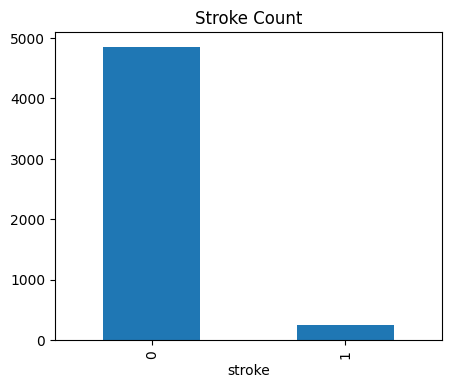

In [5]:
plt.figure(figsize=(5,4))
df["stroke"].value_counts().plot(kind="bar")
plt.title("Stroke Count")
plt.show()

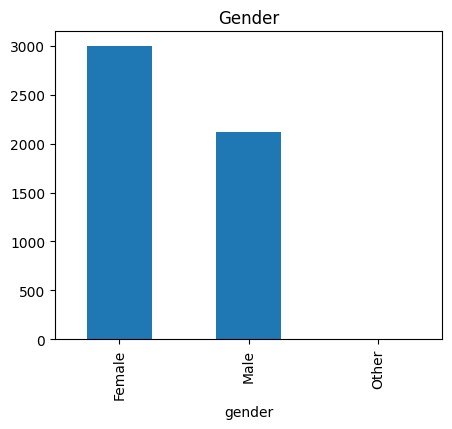

In [6]:
plt.figure(figsize=(5,4))
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender")
plt.show()

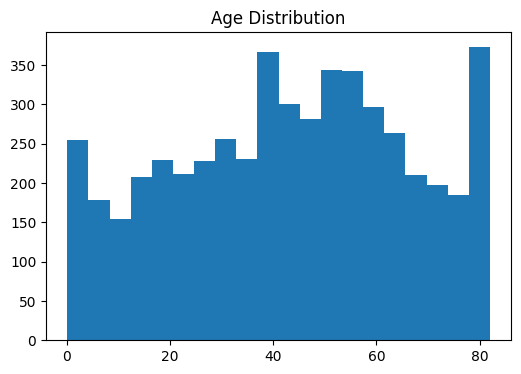

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

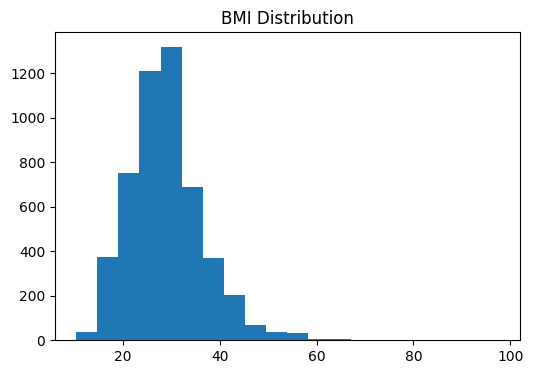

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.show()


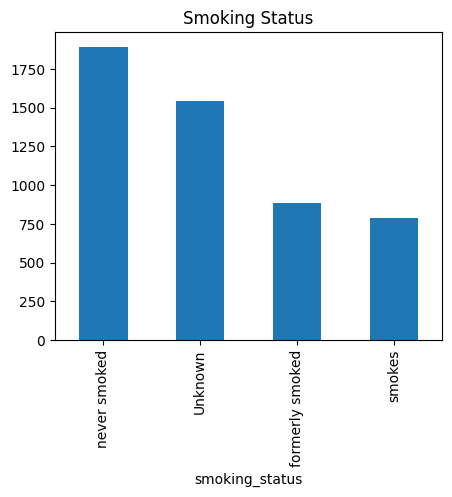

In [9]:
plt.figure(figsize=(5,4))
df["smoking_status"].value_counts().plot(kind="bar")
plt.title("Smoking Status")
plt.show()

In [10]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


In [11]:
X = df.drop("stroke", axis=1)
y = df["stroke"]



In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [15]:

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9393346379647749
Confusion Matrix
[[960   0]
 [ 62   0]]
Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
print("Healthcare Data Analysis Report")
print("Total Patients:", len(df))
print("Stroke Patients:", len(df[df["stroke"] == 1]))
print("Non Stroke Patients:", len(df[df["stroke"] == 0]))
print("Average Age:", round(df["age"].mean(), 2))
print("Average BMI:", round(df["bmi"].mean(), 2))
print("Average Glucose Level:", round(df["avg_glucose_level"].mean(), 2))
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Healthcare Data Analysis Report
Total Patients: 5110
Stroke Patients: 249
Non Stroke Patients: 4861
Average Age: 43.23
Average BMI: 28.89
Average Glucose Level: 106.15
Model Accuracy: 93.93 %
